### Seattle All Collisions Exploratory Data Analysis
This notebook serves to explore collision trends that occurred between 2015 and the most recent completed month of 2026 (August). This allows us to further understand how collision trends have evolved as a result of the Vision Zero initiative and reacted to worldwide anomalies such as COVID-19.

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

### All Collision Dataset

In [51]:
gdf = gpd.read_parquet('../data/cleaned/Collision_All_Filtered.parquet')
gdf

,OBJECTID,SE_ANNO_CAD_DATA,INCKEY,COLDETKEY,REPORTNO,STATUS,ADDRTYPE,INTKEY,LOCATION,EXCEPTRSNCODE,...,HOUR,WEATHER_RAW,ROADCOND_RAW,LIGHTCOND_RAW,JUNCTIONTYPE_RAW,UNDERINFL_RAW,Day_of_Week,Season,GEOMETRY_STATUS,HAS_VALID_GEOMETRY
0,1,,384696,386236,EF67714,Matched,I,26782.0,IRONDALE AVE W AND W BERTONA ST,None,...,9,Clear,Ice,Daylight,At Intersection (intersection related),N,Wednesday,Winter,valid,True
1,2,,382571,384091,3931753,Matched,B,NaN,1ST AVE S BETWEEN S FIDALGO ST AND EAST MARGIN...,None,...,6,Clear,Dry,Daylight,Mid-Block (not related to intersection),N,Monday,Spring,valid,True
2,3,,382297,383817,EF97031,Unmatched,B,NaN,47TH AVE NE BETWEEN NE 70TH W ST AND NE 71ST ST,None,...,0,None,None,None,Mid-Block (not related to intersection),None,Friday,Spring,valid,True
3,4,,382328,383848,EF97000,Matched,I,30509.0,4TH AVE S AND S JACKSON ST,None,...,9,Clear,Dry,Daylight,At Intersection (intersection related),N,Friday,Spring,valid,True
4,5,,382682,384202,EF99053,Unmatched,B,NaN,BEACON ER AVE S BETWEEN S EDDY ST AND S MORGAN ST,None,...,0,None,None,None,Mid-Block (not related to intersection),None,Monday,Summer,valid,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109035,261877,,387345,388885,EG46574,Unmatched,B,NaN,E HARRISON ST BETWEEN 15TH N AVE E AND 16TH AVE E,None,...,0,None,None,None,Mid-Block (not related to intersection),None,Thursday,Fall,valid,True
109036,261878,,389104,390644,EG60031,Matched,I,33046.0,1ST AVE S AND EAST MARGINAL WAY S,None,...,15,Raining,Wet,Daylight,At Intersection (intersection related),N,Tuesday,Winter,valid,True
109037,261879,,387459,388999,3924867,Matched,I,29622.0,1ST AVE AND MARION ST,None,...,0,Clear,Dry,Dark - Street Lights On,At Intersection (intersection related),N,Friday,Winter,valid,True
109038,261880,,387840,389380,EG45297,Matched,I,29801.0,BROADWAY AND JAMES ST,None,...,7,Overcast,Dry,Daylight,At Intersection (intersection related),N,Tuesday,Fall,valid,True


In [52]:
gdf.columns

Index(['OBJECTID', 'SE_ANNO_CAD_DATA', 'INCKEY', 'COLDETKEY', 'REPORTNO',
       'STATUS', 'ADDRTYPE', 'INTKEY', 'LOCATION', 'EXCEPTRSNCODE',
       'EXCEPTRSNDESC', 'PERSONCOUNT', 'PEDCOUNT', 'PEDCYLCOUNT', 'VEHCOUNT',
       'INJURIES', 'SERIOUSINJURIES', 'FATALITIES', 'INCDATE', 'INCDTTM',
       'JUNCTIONTYPE', 'SDOT_COLCODE', 'SDOT_COLDESC', 'INATTENTIONIND',
       'UNDERINFL', 'WEATHER', 'ROADCOND', 'LIGHTCOND', 'DIAGRAMLINK',
       'REPORTLINK', 'PEDROWNOTGRNT', 'SDOTCOLNUM', 'SPEEDING', 'ST_COLCODE',
       'ST_COLDESC', 'SEGLANEKEY', 'CROSSWALKKEY', 'HITPARKEDCAR', 'SPDCASENO',
       'SOURCE', 'SOURCEDESC', 'ADDDTTM', 'MODDTTM', 'ST_COLLISIONTYPE',
       'MAXSEVERITYCODE', 'SHAREDMICROMOBILITYCD', 'SHAREDMICROMOBILITYDESC',
       'ADDR_SEGINTKEY', 'ALLEY', 'DIRIMPACTUNIT1CD', 'DIRIMPACTUNIT1DESC',
       'DIRIMPACTUNIT2CD', 'DIRIMPACTUNIT2DESC', 'DIRPRIORUNIT1CD',
       'DIRPRIORUNIT1DESC', 'DIRPRIORUNIT2CD', 'DIRPRIORUNIT2DESC', 'FATALITY',
       'NONSERIOUSINJURY', 'P

### Creating monthly time series visualization method
This method allows us to produce time series visualization by month. This method is especially useful when producing time series visualizations with filtered data.

In [53]:
def monthly_counts_time_series(df, title):
    df = df.groupby(["YEAR", "MONTH"]).size().reset_index(name="COLLISION_COUNT")
    df["DATE"] = pd.to_datetime({
    "year": df["YEAR"],
    "month": df["MONTH"],
    "day": 1
    })
    sns.lineplot(df, x='DATE', y='COLLISION_COUNT', color='steelblue')
    plt.title(title)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

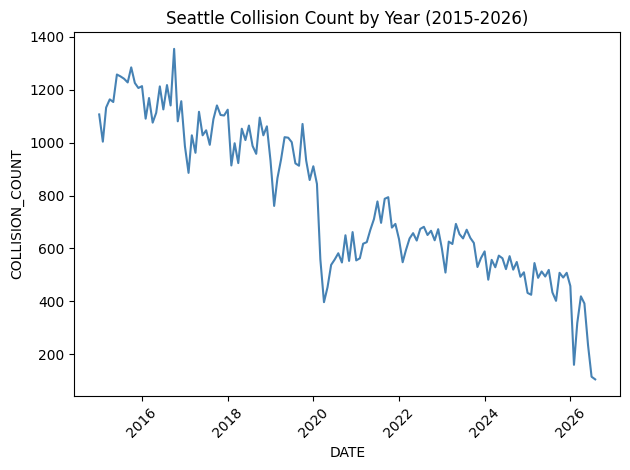

In [54]:
monthly_counts_time_series(gdf, "Seattle Collision Count by Year (2015-2026)")

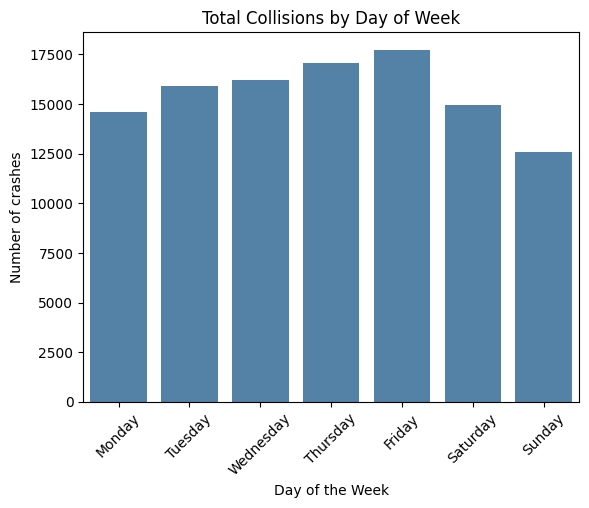

In [55]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

sns.countplot(gdf, x='Day_of_Week', order=day_order, color='steelblue')
plt.title('Total Collisions by Day of Week')
plt.xlabel('Day of the Week')
plt.ylabel('Number of crashes')
plt.xticks(rotation=45)
plt.show()

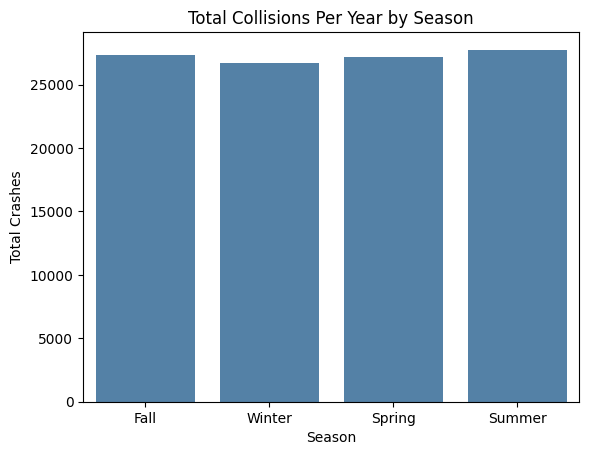

In [56]:
order = ['Fall', 'Winter', 'Spring', 'Summer']
sns.countplot(gdf, x='Season', order=order, color='steelblue')
plt.title('Total Collisions Per Year by Season')
plt.xlabel('Season')
plt.ylabel('Total Crashes')
plt.show()

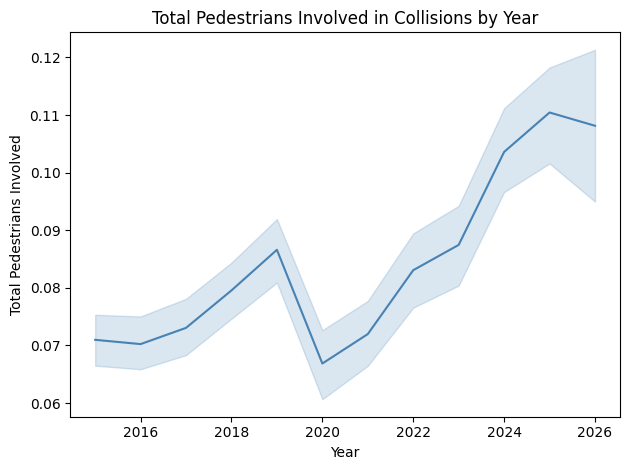

In [57]:
gdf['TOTAL_PED'] = gdf['PEDCOUNT'] + gdf['PEDCYLCOUNT']
sns.lineplot(gdf, x='YEAR', y='TOTAL_PED', color='steelblue')
plt.title('Total Pedestrians Involved in Collisions by Year')
plt.xlabel('Year')
plt.ylabel('Total Pedestrians Involved')
plt.tight_layout()
plt.show()

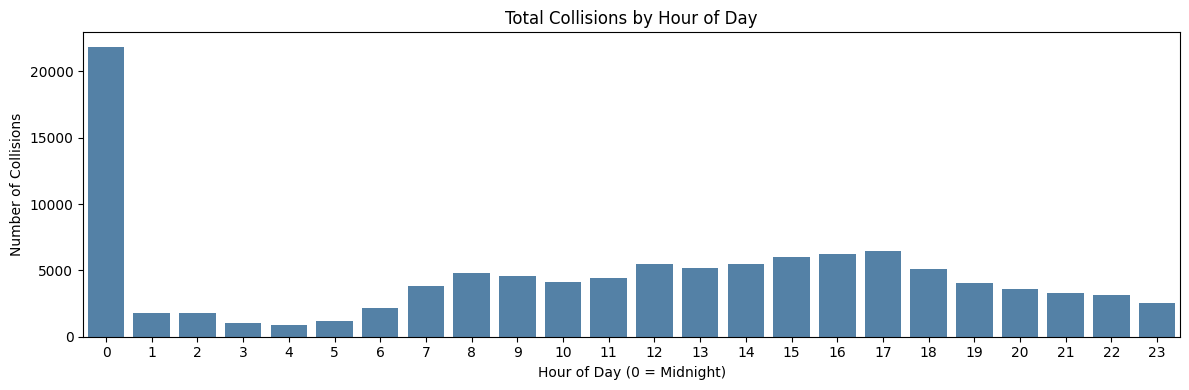

In [58]:
plt.figure(figsize=(12, 4))
hour_counts = gdf.groupby('HOUR').size().reset_index(name='COUNT')
sns.barplot(data=hour_counts, x='HOUR', y='COUNT', color='steelblue')
plt.title('Total Collisions by Hour of Day')
plt.xlabel('Hour of Day (0 = Midnight)')
plt.ylabel('Number of Collisions')
plt.tight_layout()
plt.show()

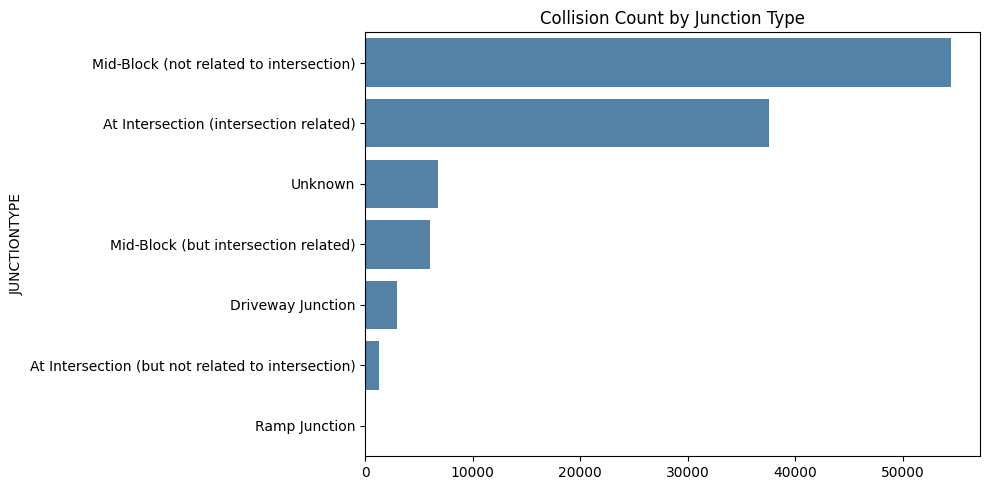

In [59]:
plt.figure(figsize=(10,5))
gdf_junc = gdf.groupby('JUNCTIONTYPE').size().sort_values(ascending=False)
sns.barplot(y=gdf_junc.index, x=gdf_junc.values, color='steelblue')
plt.title('Collision Count by Junction Type')
plt.tight_layout()
plt.show()

In [60]:
gdf.groupby("JUNCTIONTYPE").size()

JUNCTIONTYPE
At Intersection (but not related to intersection)     1284
At Intersection (intersection related)               37556
Driveway Junction                                     2951
Mid-Block (but intersection related)                  6009
Mid-Block (not related to intersection)              54427
Ramp Junction                                           59
Unknown                                               6754
dtype: int64

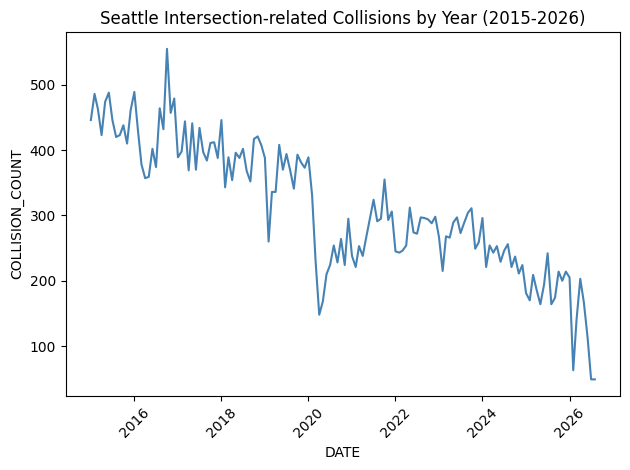

In [61]:
gdf_intersection = gdf[gdf["JUNCTIONTYPE"].isin(["At Intersection (intersection related)", "Mid-Block (but intersection related)"])]
monthly_counts_time_series(gdf_intersection, "Seattle Intersection-related Collisions by Year (2015-2026)")

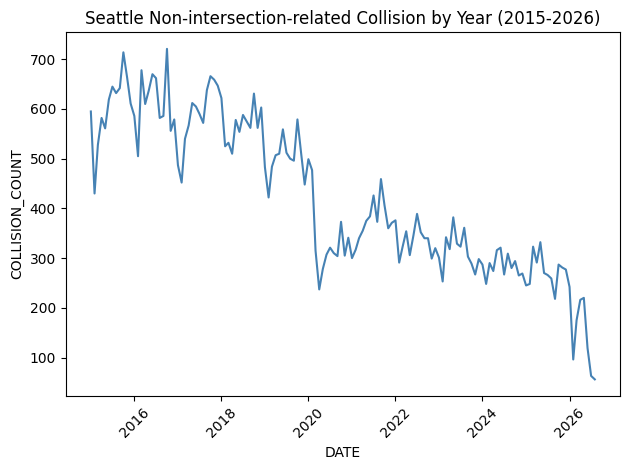

In [62]:
gdf_other = gdf[gdf["JUNCTIONTYPE"].isin(["At Intersection (but not related to intersection)", "Driveway Junction", "Mid-Block (not related to intersection)", "Ramp Junction"])]
monthly_counts_time_series(gdf_other, "Seattle Non-intersection-related Collision by Year (2015-2026)")

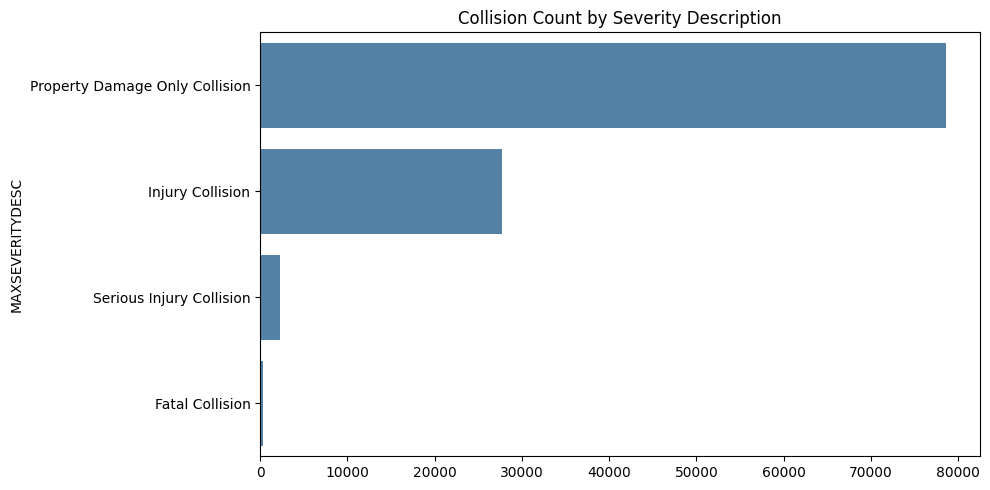

In [63]:
plt.figure(figsize=(10,5))
gdf_sev = gdf.groupby('MAXSEVERITYDESC').size().sort_values(ascending=False)
sns.barplot(y=gdf_sev.index, x=gdf_sev.values, color='steelblue')
plt.title('Collision Count by Severity Description')
plt.tight_layout()
plt.show()

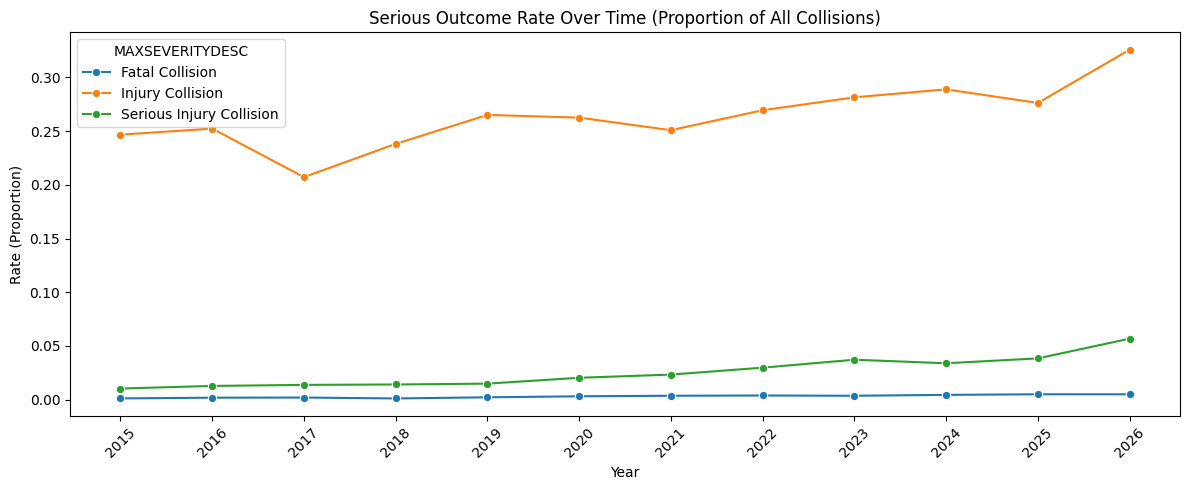

In [64]:
severity_year = (
    gdf.groupby(['YEAR', 'MAXSEVERITYDESC'])
    .size()
    .reset_index(name='COUNT')
)
severity_year['TOTAL'] = severity_year.groupby('YEAR')['COUNT'].transform('sum')
severity_year['RATE'] = severity_year['COUNT'] / severity_year['TOTAL']

serious = severity_year[severity_year['MAXSEVERITYDESC'].str.contains('Injury|Fatal', case=False, na=False)]

plt.figure(figsize=(12, 5))
sns.lineplot(data=serious, x='YEAR', y='RATE', hue='MAXSEVERITYDESC', marker='o')
plt.title('Serious Outcome Rate Over Time (Proportion of All Collisions)')
plt.xlabel('Year')
plt.ylabel('Rate (Proportion)')
plt.xticks(sorted(serious['YEAR'].unique()), rotation=45)
plt.tight_layout()
plt.show()

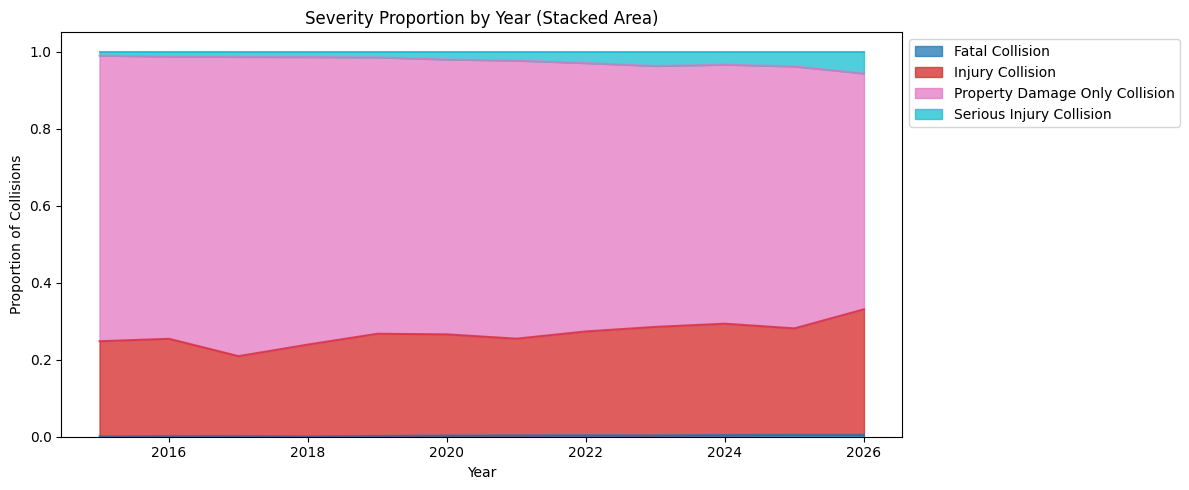

In [65]:
severity_pivot = severity_year.pivot(index='YEAR', columns='MAXSEVERITYDESC', values='RATE').fillna(0)

severity_pivot.plot(kind='area', stacked=True, figsize=(12, 5), alpha=0.75, colormap='tab10')
plt.title('Severity Proportion by Year (Stacked Area)')
plt.xlabel('Year')
plt.ylabel('Proportion of Collisions')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

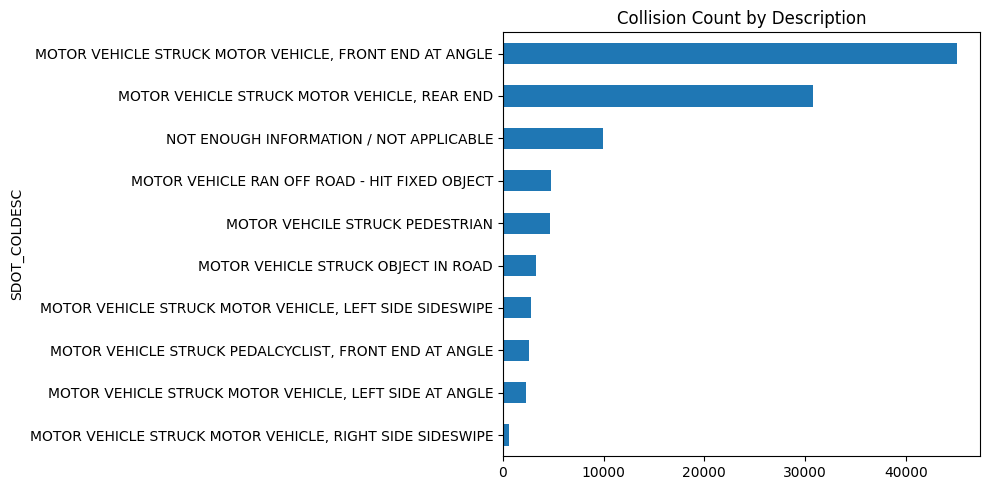

In [66]:
plt.figure(figsize=(10,5))
gdf_sev = gdf.groupby('SDOT_COLDESC').size().sort_values(ascending=False).head(10).sort_values(ascending=True)
gdf_sev.plot(kind='barh')
plt.title('Collision Count by Description')
plt.tight_layout()
plt.show()

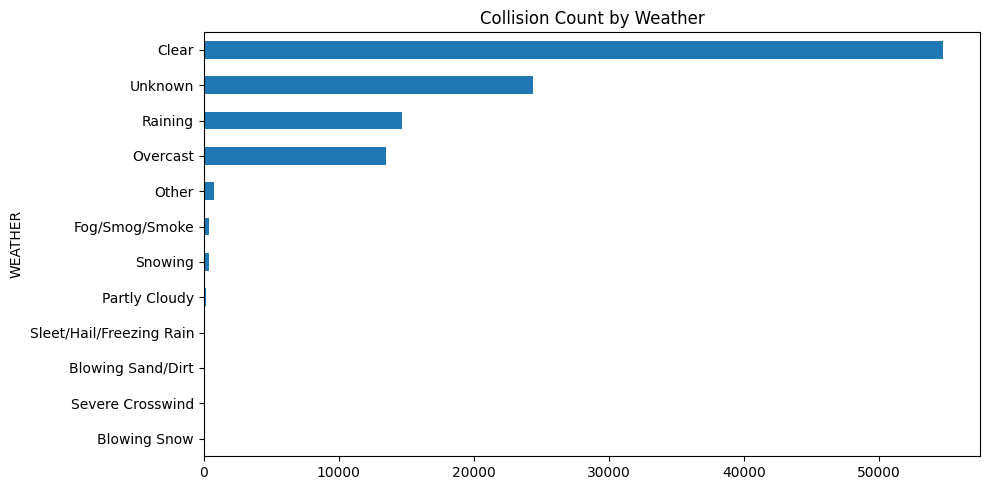

In [67]:
plt.figure(figsize=(10,5))
gdf_sev = gdf.groupby('WEATHER').size().sort_values(ascending=True)
gdf_sev.plot(kind='barh')
plt.title('Collision Count by Weather')
plt.tight_layout()
plt.show()

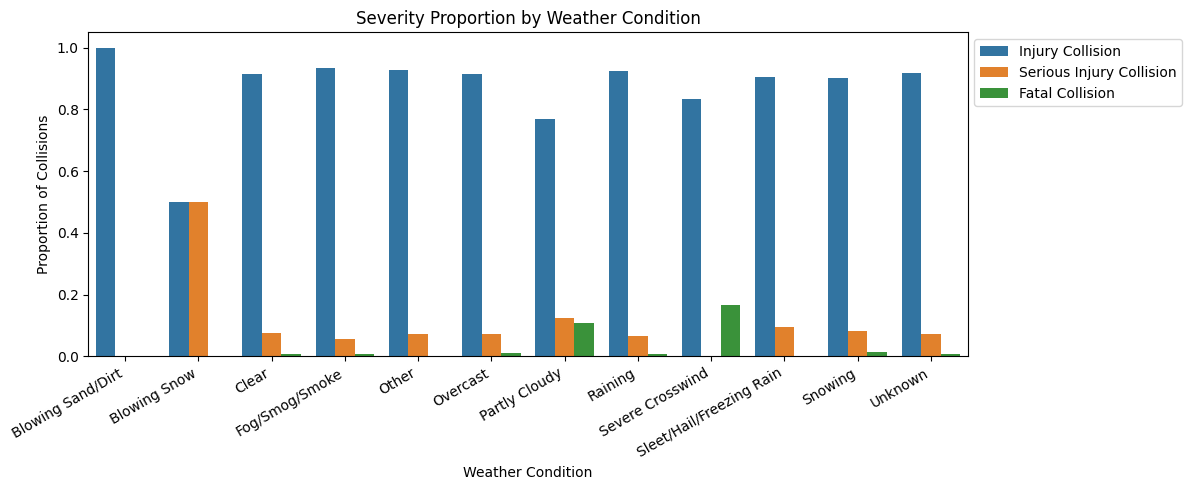

In [70]:
weather_sev = (
    gdf.groupby(['WEATHER', 'MAXSEVERITYDESC'])
    .size()
    .reset_index(name='COUNT')
)
weather_sev = weather_sev[weather_sev['MAXSEVERITYDESC'].str.contains('Injury|Fatal')]
weather_sev['PROPORTION'] = weather_sev.groupby('WEATHER')['COUNT'].transform(lambda x: x / x.sum())

plt.figure(figsize=(12, 5))
sns.barplot(data=weather_sev, x='WEATHER', y='PROPORTION', hue='MAXSEVERITYDESC')
plt.title('Severity Proportion by Weather Condition')
plt.xlabel('Weather Condition')
plt.ylabel('Proportion of Collisions')
plt.xticks(rotation=30, ha='right')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

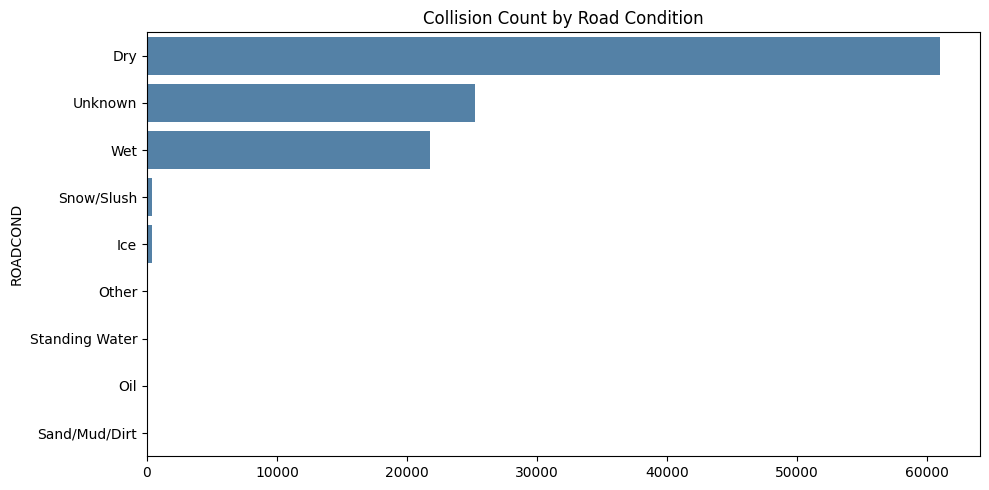

In [71]:
plt.figure(figsize=(10,5))
gdf_sev = gdf.groupby('ROADCOND').size().sort_values(ascending=False)
sns.barplot(y=gdf_sev.index, x=gdf_sev.values, color='steelblue')
plt.title('Collision Count by Road Condition')
plt.tight_layout()
plt.show()

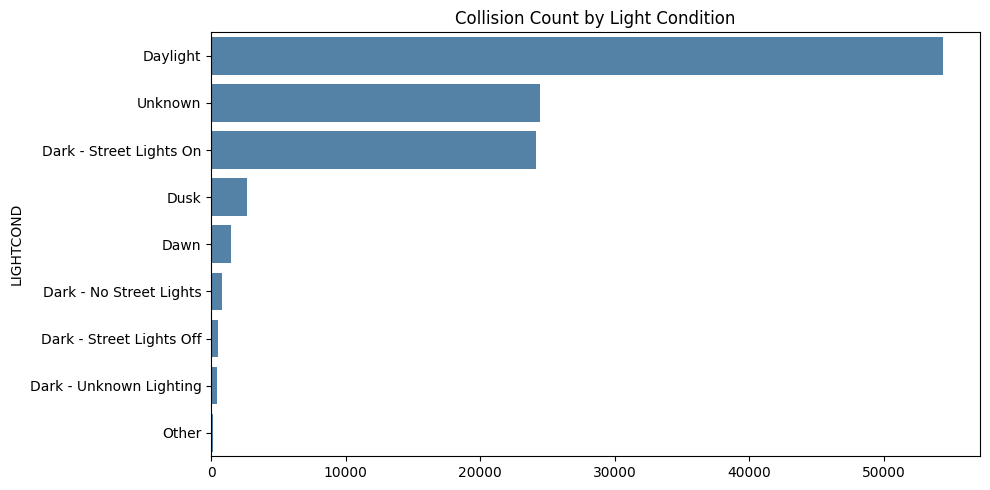

In [72]:
plt.figure(figsize=(10,5))
gdf_sev = gdf.groupby('LIGHTCOND').size().sort_values(ascending=False)
sns.barplot(y=gdf_sev.index, x=gdf_sev.values, color='steelblue')
plt.title('Collision Count by Light Condition')
plt.tight_layout()
plt.show()